# Climate forcing data

Now that we have all the **static catchment data**, we can turn to the **climate forcing** needed for MATILDA.

In this notebook we will...

1. request the **reference elevation** of the forcing data,
2. request **ERA5-Land temperature and precipitation** for the catchment,
3. inspect the returned time series,
4. and store the results for the next workflow steps.

🌦️ The aim is not only to obtain the data, but also to make each step easy to follow. Even when code cells are hidden in the final Jupyter Book, the printed outputs and figures should still show a clear workflow.

To get started, we read the settings from the `config.ini` file again.

We will need:

- paths for **input**, **output**, and **figures**,
- the name of the output **GeoPackage** from Notebook 1,
- whether **projections** are enabled,
- whether a refreshed **ZIP archive** should be created,
- and the **MATILDA-Webservice URL** plus **API key** for the requests.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import ast
import configparser
import os

config = configparser.ConfigParser()
config.read("config.ini")

dir_input = config["FILE_SETTINGS"]["DIR_INPUT"]
dir_output = config["FILE_SETTINGS"]["DIR_OUTPUT"]
dir_figures = config["FILE_SETTINGS"]["DIR_FIGURES"]
output_gpkg = dir_output + config["FILE_SETTINGS"]["GPKG_NAME"]
scenarios = config.getboolean("CONFIG", "PROJECTIONS")
show_map = config.getboolean("CONFIG", "SHOW_MAP")
zip_output = config.getboolean("CONFIG", "ZIP_OUTPUT")

plt_style = ast.literal_eval(config["CONFIG"]["PLOT_STYLE"])

print(f"Output GeoPackage: {output_gpkg}")
print(f"Figure directory:  {dir_figures}")

Output GeoPackage: output/catchment_data.gpkg
Figure directory:  output/figures/


If you have decided to back up your output files, you can now load them.

In [2]:
import zipfile

if zip_output:
    with zipfile.ZipFile("output_download.zip", "r") as z:
        z.extractall(dir_output)

    print(f'Extracted "output_download.zip" to "{dir_output}".')

Next, we load the **catchment geometry** from Notebook 1.

This geometry is the spatial reference for all following requests:

- the **reference elevation** is calculated for this catchment,
- and the **ERA5-Land time series** are aggregated to exactly this area.

In [3]:
import geopandas as gpd
import json
import matplotlib.pyplot as plt

catchment_new = gpd.read_file(output_gpkg, layer="catchment_new")
catchment_geojson = json.loads(catchment_new.to_json())

print(f"Loaded catchment layer with {len(catchment_new)} feature(s).")
print(f"Catchment CRS: {catchment_new.crs}")
display(catchment_new.head(1))

Loaded catchment layer with 1 feature(s).
Catchment CRS: EPSG:4326


,LABEL,area,geometry
0,1,3.017655e+08,"MULTIPOLYGON (((78.14784 42.05075, 78.14734 42..."


## ERA5-Land reference elevation

ERA5-Land provides the atmospheric forcing variables we need, but for a lumped hydrological model we also need one representative **reference elevation** of the forcing data. 

This elevation is derived from the **surface geopotential**:

> The geopotential height can be calculated by dividing the geopotential by the Earth's gravitational acceleration,
> \(g = 9.80665\; m\; s^{-2}\).

In practical terms, this gives us a representative elevation for the catchment-wide forcing data — similar in spirit to the elevation of a weather station.

✨ In the notebook, we simply request this value from the MATILDA-Webservice and inspect the result.

In [4]:
from tools.geetools import get_geopotential_webservice

geopot_data = get_geopotential_webservice(catchment_new)
mean_val = geopot_data["geopotential_mean"]
ele_dat = geopot_data["elevation_m"]

✅ Reference elevation successfully retrieved.
Geopotential mean:	32556.80 m2 s-2
Reference elevation:	3319.87 m a.s.l.
Elapsed time:		1.0 s


***

## ERA5-Land temperature and precipitation data

### Select the date range
The selected time period depends on whether the workflow should prepare **only past forcing data** or also support later **scenario processing**.

- If `PROJECTIONS=False`, the date range is taken directly from the `config.ini`.
- If `PROJECTIONS=True`, the workflow requests the historical period from **1979 onward** to provide a broader baseline for later bias adjustment.

In [5]:
if scenarios is True:
    date_range = ["1979-01-01", "2026-01-01"]
else:
    date_range = ast.literal_eval(config["CONFIG"]["DATE_RANGE"])

print(f"The selected date range is {date_range[0]} to {date_range[1]}")

The selected date range is 1979-01-01 to 2026-01-01


### Download ERA5-Land data
For the MATILDA model, the key meteorological inputs are:

- **air temperature**
- **precipitation**

We request both as **catchment-aggregated daily time series** for the selected period.

The returned values are then converted into a compact `pandas.DataFrame`:

- temperature from **Kelvin** to **°C**,
- precipitation from **meters** to **millimeters**.

> 💡 **How are the ERA5-Land data aggregated?**  
> The ERA5-Land data has an approximate spatial resolution of 9 km. Depending on the size of your catchment area, the data may cover many or just a few grid cells. The web service calculates one area-weighted, catchment-wide average for each day. This means each cell is weighted according to its overlap with the catchment area.

In [6]:
from tools.geetools import get_climate_data_webservice

df = get_climate_data_webservice(catchment_new, date_range)
display(df.head())

✅ ERA5-Land forcing data successfully retrieved.
Date range: 1979-01-01 to 2025-12-31
Number of daily records: 17167
Elapsed time: 15.5 s


,dt,temp,temp_c,prec
0,1979-01-01,257.521054,-15.628946,0.026909
1,1979-01-02,256.569882,-16.580118,0.004765
2,1979-01-03,257.998206,-15.151794,0.001595
3,1979-01-04,258.441277,-14.708723,0.279193
4,1979-01-05,258.189412,-14.960588,0.106927


The first rows already show the structure of the forcing data:

- a timestamp,
- the original temperature,
- the converted temperature in °C,
- precipitation converted to mm per day.

In [7]:
import pandas as pd

summary_df = pd.DataFrame(
    {
        "variable": ["Temperature", "Precipitation"],
        "minimum": [df["temp_c"].min(), df["prec"].min()],
        "mean": [df["temp_c"].mean(), df["prec"].mean()],
        "maximum": [df["temp_c"].max(), df["prec"].max()],
        "unit": ["°C", "mm d-1"],
    }
)
print("Quick summary statistics of the forcing data:")
display(summary_df)

Quick summary statistics of the forcing data:


,variable,minimum,mean,maximum,unit
0,Temperature,-26.441147,-4.236060,15.152431,°C
1,Precipitation,-0.000024,3.618221,61.645001,mm d-1


A time series plot provides a first impression of the seasonal signal and the variability of both variables.

In [8]:
print( df[["dt", "temp_c", "prec"]])

              dt     temp_c      prec
0     1979-01-01 -15.628946  0.026909
1     1979-01-02 -16.580118  0.004765
2     1979-01-03 -15.151794  0.001595
3     1979-01-04 -14.708723  0.279193
4     1979-01-05 -14.960588  0.106927
...          ...        ...       ...
17162 2025-12-27 -15.847240  0.013149
17163 2025-12-28 -13.449476  0.238839
17164 2025-12-29 -15.657843  0.552368
17165 2025-12-30 -14.646669  0.050462
17166 2025-12-31 -10.610861  1.756811

[17167 rows x 3 columns]


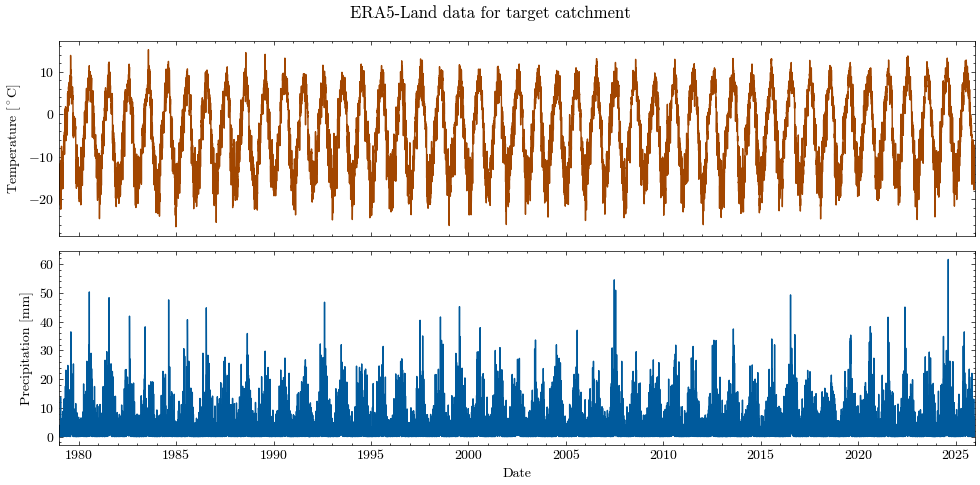

Saved overview plot to "output/figures/NB2_ERA5_Temp_Prec.png".


In [9]:
import matplotlib.dates as mdates
import scienceplots

plt.style.use(plt_style)

axes = df[["dt", "temp_c", "prec"]].plot.line(
    x="dt",
    subplots=True,
    legend=False,
    figsize=(10, 5),
    title="ERA5-Land data for target catchment",
    color={"temp_c": "#A24600", "prec": "#005A9C"},
)

axes[0].set_ylabel("Temperature [$^\circ$C]")
axes[1].set_ylabel("Precipitation [mm]")
axes[1].set_xlabel("Date")
axes[1].xaxis.set_minor_locator(mdates.YearLocator())
plt.xlim(date_range)
plt.tight_layout()
plt.savefig(dir_figures + "NB2_ERA5_Temp_Prec.png")
plt.show()
print(f'Saved overview plot to "{dir_figures}NB2_ERA5_Temp_Prec.png".')

For long time series, a short close-up can be useful as well 🔎

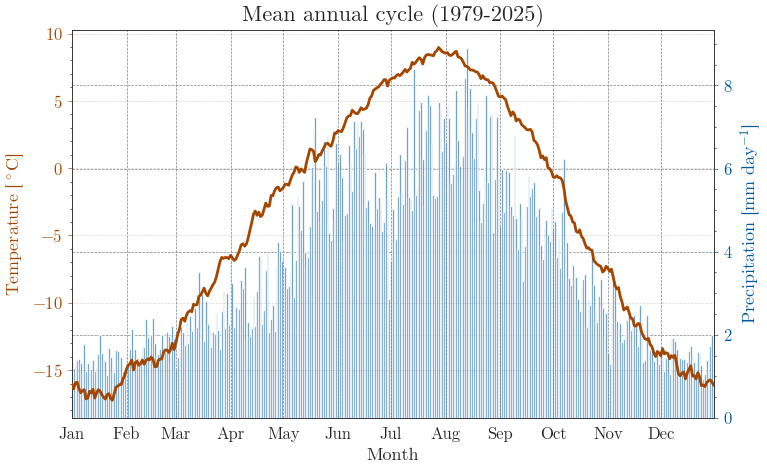

Saved climatology plot to "output/figures/NB2_ERA5_Temp_Prec_clim.png".


In [10]:
from tools.plots import plot_mean_annual_cycle

fig, ax1, ax2, clim = plot_mean_annual_cycle(df)
fig.savefig(dir_figures + "NB2_ERA5_Temp_Prec_clim.png")

print(f'Saved climatology plot to "{dir_figures}NB2_ERA5_Temp_Prec_clim.png".')

## Store data for next steps

To continue in the workflow, we store two outputs:

- the **ERA5-Land forcing time series** as `ERA5L.csv`,
- and the **reference elevation** in `settings.yml` as `ele_dat`.

In [11]:
era5l_path = dir_output + "ERA5L.csv"
df.to_csv(era5l_path, header=True, index=False)
print(f'ERA5-Land forcing data written to "{era5l_path}".')

ERA5-Land forcing data written to "output/ERA5L.csv".


In [12]:
from tools.helpers import update_yaml

update_yaml(dir_output + "settings.yml", {"ele_dat": float(ele_dat)})
print(f'Updated "{dir_output}settings.yml" with ele_dat = {float(ele_dat):.2f}.')

Data successfully written to YAML at output/settings.yml
Updated "output/settings.yml" with ele_dat = 3319.87.


Finally, if requested in the `config.ini`, we refresh `output_download.zip` so that all newly generated output files can be downloaded together.

In [13]:
import shutil

if zip_output:
    shutil.make_archive("output_download", "zip", "output")
    print('Output folder refreshed and available as "output_download.zip".')
else:
    print("ZIP output disabled in config.ini")

ZIP output disabled in config.ini


✅ Notebook 2 is complete. You can now continue with [Notebook 3](Notebook3_CMIP6.ipynb).